# Single-site traces

author: laquitainesteeve@gmail.com

Plot single-electrode voltage traces

Execution time: 20 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

Resources required:
- 180 GB RAM

## Setup

Prerequisites:

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download recordings: "_notebooks/0_download_recordings.ipynb_"


In [12]:
# setup packages
%load_ext autoreload
%autoreload 2
import os
from os.path import join
import numpy as np
from matplotlib import pyplot as plt
import spikeinterface as si
from spikeinterface import preprocessing as spre
import yaml
import warnings
import matplotlib as mpl
import pandas as pd

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
print("Spikeinterface:", si.__version__)

# move to project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(proj_path)

# spikebias package
from src.nodes.validation import noise

# SETUP PARAMETERS
FREQ_MIN = 300         # high-pass filtering cutoff frequency
REC_DURATION_SEC = 600 # duration of recording examined
LAYER = "L5"           # layer 5
DURATION = 1.01        # period examined in figure
SF_S = 40000           # sampling frequency of npx_spont (biophy)
ID_PERIOD_SILI = 10
L5_SITE_SILI = 0

YLIM = (-100, 30)
SITE_B = 352
SITE_E = 232
GAIN_TO_UV = 0.195

# spontaneous biophy. model
RAW_PATH_ns = "dataset/00_raw/recording_npx_spont"

# setup figure parameters
COMPUTE_FIG_DATA = False
SAVE_FIG_DATA = False
LOAD_FIG_DATA = True
SAVE_FIG = True

# get paths of saved figures
with open(join(proj_path, "conf/figures.yml"), "r", encoding="utf-8") as yaml_file:
    fig_data_paths = yaml.load(yaml_file, Loader=yaml.FullLoader)

# figure settings
FIG_SIZE = (0.9, 0.7)

# colors
COLOR_MS = [0.9, 0.14, 0.15]

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["lines.linewidth"] = 0.5
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 
plt.rcParams["xtick.minor.width"] = 0.5 
plt.rcParams["ytick.major.width"] = 0.5 
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# keeps text as text in saved svg
mpl.rcParams['svg.fonttype'] = 'none'   

# legend
savefig_cfg = {"transparent":True, "dpi":300}
legend_cfg = {"frameon": False, "handletextpad": 0.1}
tight_layout_cfg = {"pad": 0.5}
LG_FRAMEON = False              # no legend frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Spikeinterface: 0.100.8


## Clear RAM

In [4]:
import getpass; password = getpass.getpass("Enter your sudo password: ")
!sync; echo {password} | sudo -S sh -c 'echo 1 > /proc/sys/vm/drop_caches'

[sudo] password for steeve: Sorry, try again.
[sudo] password for steeve: 
sudo: no password was provided
sudo: 1 incorrect password attempt


## Spontaneous biophysical model 

### Compute

* execution time: 3 min

In [5]:
%%time

# setup parameters
L5_SITE = 21

# compute figure data
if COMPUTE_FIG_DATA:

    # load raw recording extractors
    Rec = si.load_extractor(RAW_PATH_ns)

    # get metadata
    sfreq = Rec.get_sampling_frequency()
    layers = Rec.get_property("layers")

    # extract first 10 min of the recording extractors 
    Rec = Rec.frame_slice(start_frame=0, end_frame=REC_DURATION_SEC*sfreq)
    print("Recording:", Rec)

    # preprocess voltage traces
    Rec = spre.astype(Rec, "int16")
    Rec = spre.highpass_filter(Rec, freq_min=FREQ_MIN)
    Rec = spre.common_reference(Rec, reference="global", operator="median")

    # select a site and period
    L5_site = np.where(layers == LAYER)[0][L5_SITE]
    one_sec_period = np.arange((ID_PERIOD_SILI - 1) * sfreq, ID_PERIOD_SILI * sfreq, 1) # one second
    traces = Rec.get_traces(channel_ids=[str(L5_site)])

    # plot figure
    fig_data = traces[one_sec_period.astype(int)]

# save figure data
if SAVE_FIG_DATA:
    
    wind_end = int(np.floor(len(traces)/sfreq))
    bkg_noise = noise.measure_trace_noise(traces[one_sec_period.astype(int)], int(sfreq), wind_end)
    np.save(fig_data_paths["fig2b_compo_silico_npx_bkg_noise"], bkg_noise)    
    np.save(fig_data_paths["fig2b_compo_silico_npx"], fig_data)

# load figure data
elif LOAD_FIG_DATA:
    bkg_noise = np.load(fig_data_paths["fig2b_compo_silico_npx_bkg_noise"])    
    fig_data = np.load(join(proj_path, fig_data_paths["fig2b_compo_silico_npx"]))
    print("loaded figure data")
    print("nb of 1-sec windows:", len(bkg_noise))
    print("Background noise level (min MAD over windows):", min(bkg_noise))

loaded figure data
nb of 1-sec windows: 600
Background noise level (min MAD over windows): 3.239969
CPU times: user 810 µs, sys: 10 µs, total: 820 µs
Wall time: 3.54 ms


### plot

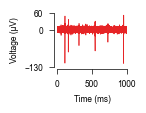

In [14]:
# setup parameters
YMAX = 60
YMIN = -130
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE)

# plot figure
ax.plot(fig_data, color=COLOR_MS)

# legend
ax.spines[["right", "top"]].set_visible(False)
ax.set_ylabel("Voltage (\u03bcV)")
ax.set_xlabel("Time (ms)")
plt.xticks([0, SF_S / 2, SF_S])
ax.set_xticklabels([0, 500, 1000])
ax.set_xlim([0, SF_S])

# disconnected
ax.spines["bottom"].set_position(("axes", -0.05))
ax.yaxis.set_ticks_position("left")
ax.spines["left"].set_position(("axes", -0.05))
ax.set_yticks([YMIN, 0, YMAX])
ax.set_ylim([YMIN, YMAX])

# save
if SAVE_FIG:
    plt.savefig("figures/8_source_data/fig2b/fig2b.svg", bbox_inches="tight")

### Save source data file

In [15]:
# time
time_ms = np.linspace(0, 1000, SF_S, endpoint=True)

# save to Excel
df = pd.DataFrame({"time_ms": time_ms, "signal": fig_data})
df.to_excel("figures/8_source_data/fig2b/fig2b.xlsx", index=False)